In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
# Load Data
df_original = pd.read_csv('Children Recode_final.csv')

# Drop unnecessary columns
df = df_original.drop(['Underweight', 'Wasting'], axis=1)

# Feature and Target selection
X = df.drop(columns=['Stunting'])
y = df['Stunting']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN Model
knn = KNeighborsClassifier(n_neighbors=19)
knn.fit(X_train, y_train)

# Predictions & Accuracy
predictions = knn.predict(X_test)
accuracy = knn.score(X_test, y_test)

accuracy


0.7745535714285714

## Stunting Prediction

In [56]:
columns_to_scale = ['Child_age', 'Age_first_sex', 'BMI', 'Mother_age_current', 'Mother_age_at_first_birth']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [57]:
knn_scaled = KNeighborsClassifier(n_neighbors=12)
knn_scaled.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=12)

In [58]:
predictions_scaled = knn_scaled.predict(X_test_scaled)
accuracy_scaled = knn_scaled.score(X_test_scaled, y_test)
print(f'Accuracy: {accuracy_scaled}')
confusion_matrix(y_test, predictions_scaled)

Accuracy: 0.7611607142857143


array([[333,  10],
       [ 97,   8]])

### K-value for the best performance

Best k value: 36


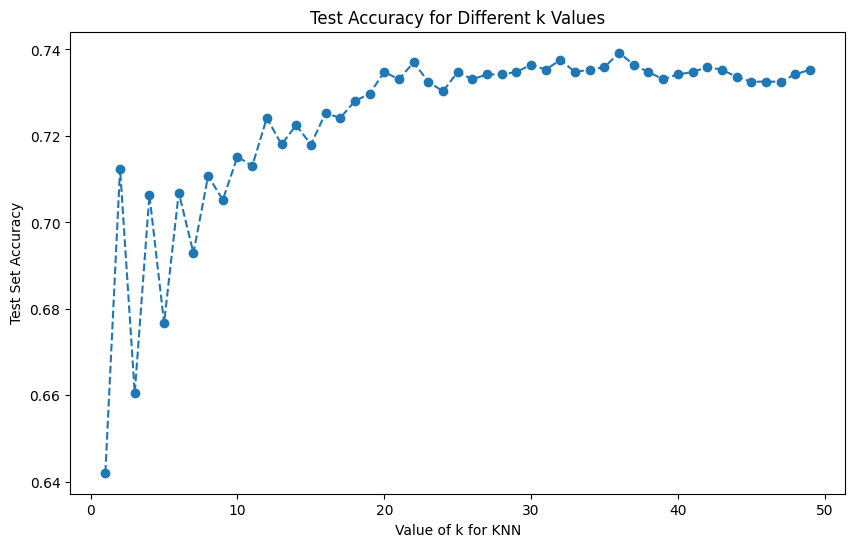

In [59]:
# Manual method
k_range = range(1, 50)
accuracy_scores = []

# Peform cross-validation for each k
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv = 10, scoring = 'accuracy') 
    accuracy_scores.append(scores.mean())

best_k = k_range[np.argmax(accuracy_scores)]
print(f"Best k value: {best_k}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracy_scores, marker='o', linestyle='--')
plt.xlabel('Value of k for KNN')
plt.ylabel('Test Set Accuracy')
plt.title('Test Accuracy for Different k Values')
plt.show()

In [ ]:
# Predictions
y_pred = knn_scaled.predict(X_test_scaled)

# Classification Report
print(classification_report(y_test, y_pred))

# ROC-AUC Score
auc = roc_auc_score(y_test, knn_scaled.predict_proba(X_test_scaled)[:,1])
print(f"ROC-AUC Score: {auc:.4f}")

              precision    recall  f1-score   support

           0       0.77      0.97      0.86       343
           1       0.44      0.08      0.13       105

    accuracy                           0.76       448
   macro avg       0.61      0.52      0.50       448
weighted avg       0.70      0.76      0.69       448

ROC-AUC Score: 0.5624


**Balancing using Synthetic Minority Oversampling Technique (SMOTE)**

In [ ]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Check new class distribution
print(y_train_balanced.value_counts())

Stunting
1    1317
0    1317
Name: count, dtype: int64


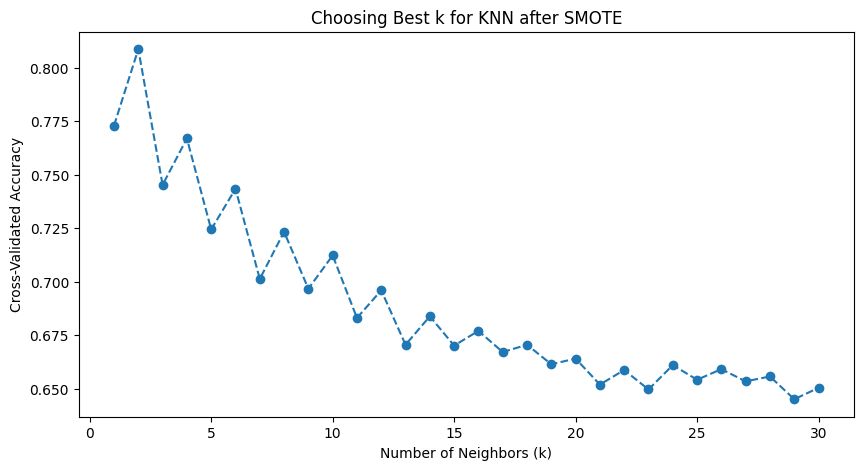

Best k after balancing: 2, Accuracy: 0.8087
Test Accuracy with best k (2): 0.6652


In [52]:
  # Finding the best k using cross-validation
k_values = range(1, 31)  
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_balanced, y_train_balanced, cv=10, scoring='accuracy')  
    cv_scores.append(scores.mean())

# Plot accuracy vs. k values
plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, marker='o', linestyle='dashed')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Choosing Best k for KNN after SMOTE')
plt.show()

# Best k selection
best_k = k_values[np.argmax(cv_scores)]
print(f"Best k after balancing: {best_k}, Accuracy: {max(cv_scores):.4f}")

# Train the best model with balanced data
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_balanced, y_train_balanced)

# Test accuracy
test_accuracy = knn_best.score(X_test_scaled, y_test)
print(f"Test Accuracy with best k ({best_k}): {test_accuracy:.4f}")

In [ ]:
# Predictions
y_pred = knn_best.predict(X_test_scaled)

# Classification Report
print(classification_report(y_test, y_pred))

# ROC-AUC Score
auc = roc_auc_score(y_test, knn_best.predict_proba(X_test_scaled)[:,1])
print(f"ROC-AUC Score: {auc:.4f}")

              precision    recall  f1-score   support

           0       0.79      0.77      0.78       343
           1       0.30      0.32      0.31       105

    accuracy                           0.67       448
   macro avg       0.54      0.55      0.55       448
weighted avg       0.67      0.67      0.67       448

ROC-AUC Score: 0.5655
